<img src="images/Image_8.png" alt="Image_8"/>

<img src="images/Image_9.png" alt="Image_9"/>

In [145]:
# Program to find measure of expected significance as a function
# of a cut value x_cut applied to measured variable x
# by Monte Carlo simulation of the likelihood ratio statistic.
# G. Cowan / RHUL Physics / December 2022

import numpy as np
import scipy.stats as stats
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14
#import pickle

In [146]:
#  Define pdfs and likelihood-ratio statisic
s_tot = 10.
b_tot = 100.
p_s = s_tot/(s_tot+b_tot)
#signal pdf
def f_s(x):
    return 3.*(1.-x)**2
#background pdf
def f_b(x):
    return 3.*x**2
#test satic - can be easily solved
def q(x):
    return np.log(1. + (s_tot/b_tot)*f_s(x)/f_b(x))

my print


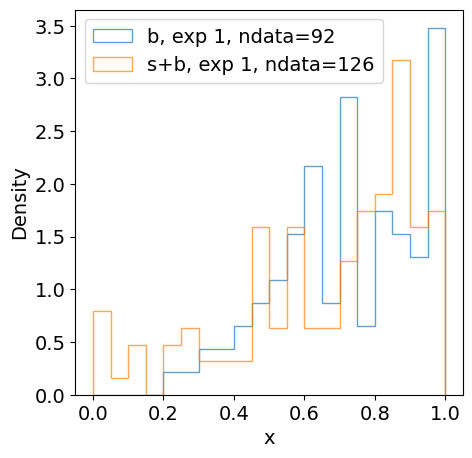

my print


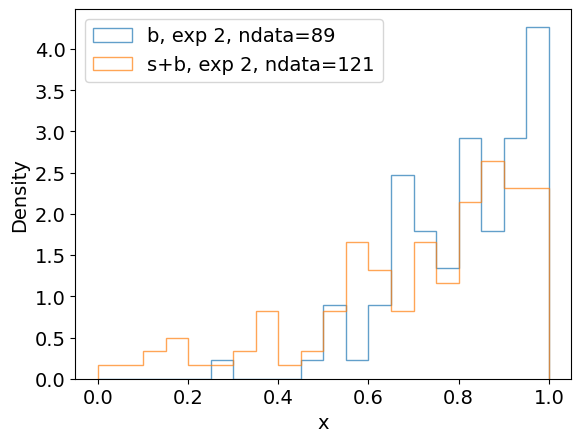

....................................................................................................

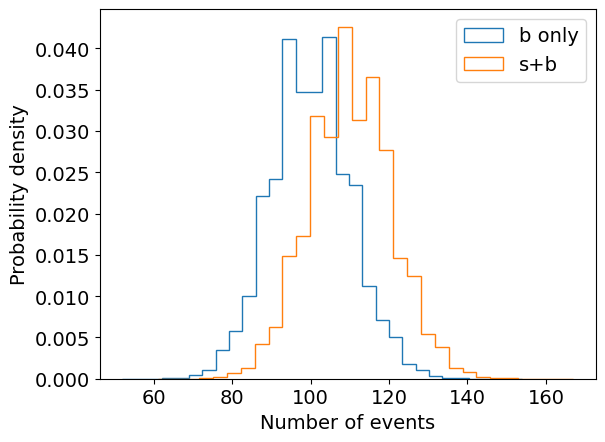

In [147]:
# Generate data under b and s+b hypotheses
qb  = [] #background only hypothesis
qsb = [] #signal + background hypothesis
numExp = 10000000
np.random.seed(seed=1234567)        # fix random seed

#loop over each of the numExp experiments

plt.figure(figsize=(5, 5))
nbHist = []
nsbHist = []
for i in range(numExp):
    n = np.random.poisson(b_tot)     # generate nob as b only
    r = np.random.uniform(0., 1., n) # generates a list of n values of r
    nbHist.append(n)
    #print(r.size)
    #this generates bkg pdf of 3x^2; uses f(x)dx=f(r)dr
    xb = r**(1./3.) 
    qb.append(np.sum(q(xb))) 
    #print(len(qb), qb)
    n = np.random.poisson(s_tot+b_tot) # # generate nob as s+b
    r1 = np.random.uniform(0., 1., n)
    r2 = np.random.uniform(0., 1., n)
    nsbHist.append(n)
    #this generates bkg pdf of 3x^2 and signal of 3(1-x)^2
    xsb = np.where(r2 < p_s, 1. - r1**(1./3.), r1**(1./3.))
    #print(xsb.size)
    qsb.append(np.sum(q(xsb)))
    if len(qsb)%(numExp/100) == 0:
            print(".", end="", flush=True)
    # added by Seema
    # To show that every experiment gives a different dataset
    if i < 2:
        #print(np.array2string(xb, formatter={'float_kind': lambda x: f"{x:.3f}"})) #formatting to print 2 decimal places
        #print(np.array2string(xsb,formatter={'float_kind': lambda x: f"{x:.3f}"}))
        print("my print")
        plt.hist(
            xb, bins=20, range=(0., 1.),
            density=True, histtype='step',
            alpha=0.7, label=f'b, exp {i+1}, ndata={xb.size}'
        )
        plt.hist(
            xsb, bins=20, range=(0., 1.),
            density=True, histtype='step',
            alpha=0.7, label=f's+b, exp {i+1}, ndata={xsb.size}'
        )
        plt.xlabel('x')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

plt.hist(nbHist, bins=30, density=True, histtype='step',label=f'b only')
plt.hist(nsbHist, bins=30, density=True, histtype='step',label=f's+b')
plt.xlabel("Number of events")
plt.ylabel("Probability density")
plt.legend()
plt.show()

print("\n")
qb  = np.array(qb)
qsb = np.array(qsb)

In [148]:
# Make and analyse histograms of q for b and s+b hypotheses
nBins = 400
qMin = 0.
qMax = 100.
qbHist, bin_edges = np.histogram(qb, bins=nBins, range=(qMin,qMax),
                                 density=True)
qsbHist, bin_edges = np.histogram(qsb, bins=nBins, range=(qMin,qMax),
                                  density=True)
med_q_sb = np.median(qsb)
print("median[q|s+b]   = {:.3f}".format(med_q_sb))

median[q|s+b]   = 21.328


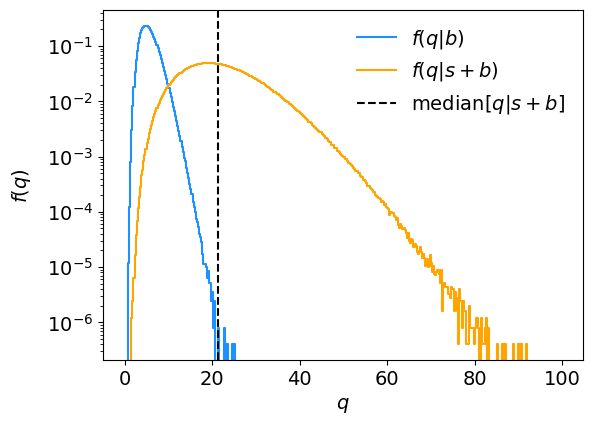

In [149]:
# Plot histograms of q
fig, ax = plt.subplots(1,1)
plt.yscale("log")
fig.subplots_adjust(bottom=0.15, left=0.15) 
plt.xlabel(r'$q$', labelpad=5)
plt.ylabel(r'$f(q)$', labelpad=10)
plt.plot(bin_edges[:-1], qbHist, drawstyle='steps-post',
         label=r'$f(q|b)$', color='dodgerblue')
plt.plot(bin_edges[:-1], qsbHist, drawstyle='steps-post',
         label=r'$f(q|s+b)$', color='orange')
ax.axvline(med_q_sb, color="black", linestyle="dashed",
           label = r'median$[q|s+b]$')
ax.legend(loc='upper right', frameon=False)
plt.show()

In [150]:
# Add code to calculate the p-value of the b-only hypothesis
# for the median q from data generated according to s+b.
# Find the corresponding significance Z.
print(len(qb[qb>=med_q_sb]))
p_val_b = len(qb[qb>=med_q_sb])/numExp
Z_b = stats.norm.ppf(1.-p_val_b)
print("median[p_b|s+b] = {:.3e}".format(p_val_b))
print("median[Z_b|s+b] = {:.3f}".format(Z_b))
print("\n")
print("\n")

7
median[p_b|s+b] = 7.000e-07
median[Z_b|s+b] = 4.825






In [153]:
# Added by Seema
# simulate observed data 
# Generate one "observed" experiment with exactly n_obs background events
# You have to be careful how you interpret it under b-only or s+b hypothesis - and that depends on what you actually observe in experiment
np.random.seed(9876543)
#np.random.seed(seed=1234569)
n_obs = 80
r_obs1 = np.random.uniform(0., 1., n_obs)
r_obs2 = np.random.uniform(0., 1., n_obs)
# Generate x according to background PDF f_b(x) = 3x^2
#x_obs = r_obs**(1./3.)
#this generates bkg pdf of 3x^2 and signal of 3(1-x)^2
#x_obs = np.where(r_obs2 < p_s, 1. - r_obs1**(1./3.), r_obs1**(1./3.))
#x_obs = np.where(r_obs2 < 0.3, 1. - r_obs1**(1./3.), r_obs1**(1./3.))
x_obs = r_obs2

# Calculate observed test statistic
#print(q(x_obs))
print(x_obs)
q_obs = np.sum(q(x_obs))
print("Number of observed events =", len(x_obs))
print("q_obs =", q_obs)
# Calculate b-only p-value
print("len(qb[qb>=q_obs]) ", len(qb[qb>=q_obs]), " numExp ", numExp)
p_val_b = len(qb[qb>=q_obs])/numExp
#N = np.sum(qb >= q_obs)
p_val_b = N / len(qb)
Z_b = stats.norm.ppf(1.-p_val_b)
print("p-value =", p_val_b, "Significance", Z_b)

[0.98343148 0.20766513 0.72754208 0.85710563 0.974697   0.33007094
 0.82240578 0.53988159 0.22195842 0.43151105 0.09458247 0.53695989
 0.42876153 0.55508851 0.06982323 0.3709017  0.79195227 0.05182964
 0.03354251 0.41007305 0.14256858 0.55603904 0.27168877 0.96652246
 0.62717832 0.95969888 0.45954793 0.33876539 0.12663473 0.0532637
 0.49758993 0.82534208 0.14003686 0.13573283 0.37030168 0.92646641
 0.64313904 0.64564239 0.10085971 0.43651409 0.47937798 0.2828905
 0.16412903 0.18326959 0.21221713 0.31608767 0.74474666 0.0152615
 0.9775905  0.18993353 0.23133517 0.12156724 0.17950906 0.39262538
 0.08421019 0.50434641 0.53227228 0.89736624 0.3343508  0.30013648
 0.06651753 0.40628912 0.27681017 0.53983787 0.46398211 0.405626
 0.63905118 0.11368818 0.19664871 0.82314008 0.3861075  0.76642279
 0.00429942 0.66315615 0.37048163 0.12292869 0.97522168 0.99889723
 0.49412751 0.11265289]
Number of observed events = 80
q_obs = 68.8676356050544
len(qb[qb>=q_obs])  0  numExp  10000000
p-value = 8.84

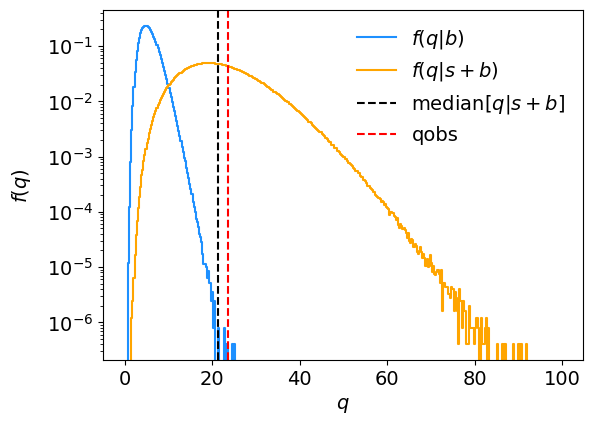

In [152]:
# Plot histograms of q
fig, ax = plt.subplots(1,1)
plt.yscale("log")
fig.subplots_adjust(bottom=0.15, left=0.15) 
plt.xlabel(r'$q$', labelpad=5)
plt.ylabel(r'$f(q)$', labelpad=10)
plt.plot(bin_edges[:-1], qbHist, drawstyle='steps-post',
         label=r'$f(q|b)$', color='dodgerblue')
plt.plot(bin_edges[:-1], qsbHist, drawstyle='steps-post',
         label=r'$f(q|s+b)$', color='orange')
ax.axvline(med_q_sb, color="black", linestyle="dashed",
           label = r'median$[q|s+b]$')
ax.axvline(q_obs, color="red", linestyle="dashed",
           label = r'qobs')
ax.legend(loc='upper right', frameon=False)
plt.show()